# PCA Dimensionality Reduction on Wine Dataset

Objective:
- Reduce dimensionality using PCA
- Visualize variance explained
- Plot 2D and 3D projections

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

## Load Wine Dataset

In [2]:
# Load dataset
wine = load_wine()
X = wine.data
y = wine.target

print("Original shape:", X.shape)

Original shape: (178, 13)


## Standardize the Features (Important for PCA)

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Apply PCA

In [4]:
# Fit PCA with all components
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio:\n", explained_variance)

Explained variance ratio:
 [0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


## Plot Variance Explained

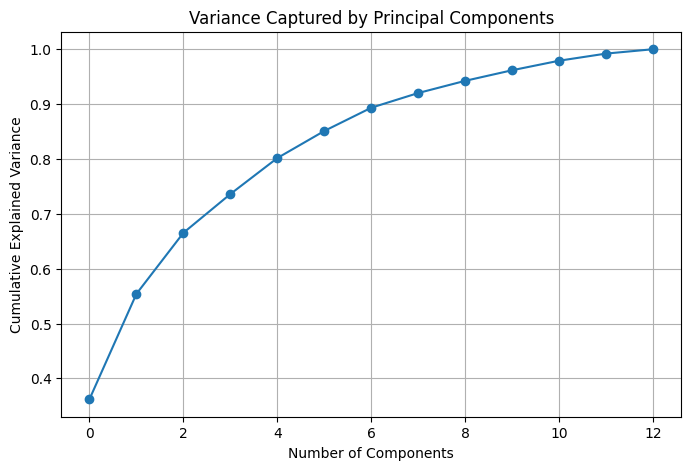

In [5]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Variance Captured by Principal Components')
plt.grid(True)
plt.show()

## 2D PCA Projection

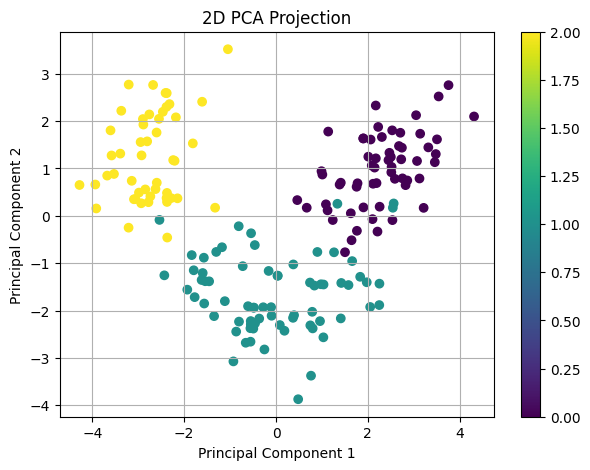

In [6]:
# Reduce to 2 components
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
scatter = plt.scatter(X_2d[:,0], X_2d[:,1], c=y)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA Projection')
plt.colorbar(scatter)
plt.grid(True)
plt.show()

## 3D PCA Projection

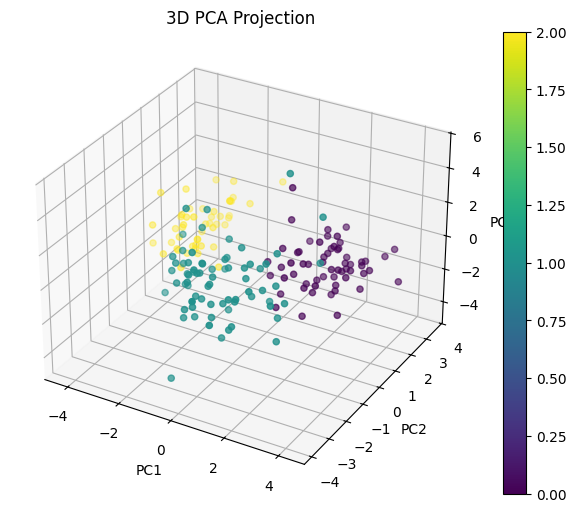

In [7]:
# Reduce to 3 components
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_3d[:,0], X_3d[:,1], X_3d[:,2], c=y)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA Projection')

plt.colorbar(sc)
plt.show()


# 🔷 Plot 1: Variance Captured by Principal Components

## 🟢 What this plot shows (simple)

* X-axis → number of principal components used
* Y-axis → how much information (variance) is preserved
* The curve rises and then flattens

👉 Meaning: first few components capture most of the data information.

---

## 🟡 What your specific graph says

From your curve:

* PC1 alone ≈ **36%** information
* First 2 PCs ≈ **55–60%**
* First 3 PCs ≈ **~66–70%**
* First 5 PCs ≈ **~85%**
* After ~8 PCs → improvement becomes very small

---

## 🔴 Key interpretation (important for exam)

**Elbow point ≈ 4–5 components**

This means:

* Original features = **13**
* Useful reduced features ≈ **4 or 5**
* Beyond that → diminishing returns

👉 PCA successfully reduces dimensionality.

---

## ✅ One-line conclusion

> Most variance of the wine dataset is captured by the first few principal components, showing effective dimensionality reduction.

---

# 🔷 Plot 2: 2D PCA Projection

## 🟢 What you are seeing (simple)

Each dot = one wine sample
Color = wine class (0, 1, 2)
Axes = new synthetic features (PC1, PC2)

PCA has compressed 13 features → 2 features.

---

## 🟡 What is GOOD in your plot

✅ Three clusters are visible
✅ Classes are mostly separated
✅ Only slight overlap

This means:

👉 PCA preserved class structure well.

---

## 🔴 Deeper interpretation

### Class separation

* Yellow cluster → clearly separated
* Purple cluster → clearly separated
* Green cluster → slightly overlapping

Meaning:

* Wine classes are inherently distinguishable
* PCA kept most discriminative information

---

## 🧠 What PC1 and PC2 are doing

* **PC1** → captures maximum variation direction
* **PC2** → captures second most variation (orthogonal)

Think of PCA as:

> Rotating the data to find the best viewing angle.

Your 2D view is already quite informative.

---

## ✅ One-line conclusion

> The first two principal components provide good visual separation among wine classes.

---

# 🔷 Plot 3: 3D PCA Projection

## 🟢 What changed from 2D

Now using:

* PC1
* PC2
* PC3

So more information is preserved.

---

## 🟡 What your 3D plot shows

Compared to 2D:

✅ Clusters are **more clearly separated**
✅ Less overlap
✅ Structure more visible

This is expected because:

> Adding PC3 adds extra variance information.

---

## 🔴 Important observation

Even in 2D separation was good.

That tells examiner:

👉 Dataset is naturally well-structured
👉 PCA is very effective here

---

## 🧠 Practical meaning

If your goal is:

* Visualization → 2D is enough
* Better separation → 3D is better
* Modeling → maybe 4–5 PCs ideal

---

# 🎯 Final Viva-Ready Summary

You can literally say this:

> PCA was applied to the Wine dataset to reduce dimensionality from 13 features. The cumulative variance plot shows that most information is captured within the first few components, with an elbow around 4–5 components. The 2D projection using the first two principal components already shows clear clustering of wine classes, indicating good preservation of class structure. The 3D projection further improves class separability by incorporating additional variance. Overall, PCA effectively reduces dimensionality while maintaining the intrinsic data structure.


